# Customer Segmentation — 02: KMeans

**Series:** 01 EDA & RFM → 02 KMeans (this notebook) → 03 DBSCAN → 04 PCA & t-SNE.

Protocol:

1. Shared preprocessing from notebook 01 (`log1p` → `StandardScaler`)
2. **k selection with three instruments**: elbow (inertia), silhouette score curve,
   and per-cluster **silhouette knife plots** — the plot that shows not just the
   average but whether every cluster clears it and whether cluster widths are balanced
3. Final model, segment profiling, revenue concentration
4. The decision layer: an action per segment

## 1. Setup, data, shared preprocessing

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

DATA_PATH = "data/online_retail.csv"
KAGGLE_DATASET = "vijayuv/onlineretail"
MIRROR_URL = (
    "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/"
    "master/data/retail-data/all/online-retail-dataset.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print("Downloaded from mirror.")
    return path


def build_rfm(path: str = DATA_PATH) -> pd.DataFrame:
    """Cleaning rules and RFM+ construction — identical to notebook 01."""
    df = pd.read_csv(path, encoding="ISO-8859-1")
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    canc = df.InvoiceNo.astype(str).str.startswith("C")
    d = df[~canc & df.CustomerID.notnull() & (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
    d["Revenue"] = d.Quantity * d.UnitPrice
    snapshot = d.InvoiceDate.max() + pd.Timedelta(days=1)
    rfm = d.groupby("CustomerID").agg(
        recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
        frequency=("InvoiceNo", "nunique"),
        monetary=("Revenue", "sum"),
        tenure=("InvoiceDate", lambda s: (snapshot - s.min()).days),
        n_products=("StockCode", "nunique"),
    )
    rfm["avg_order_value"] = rfm.monetary / rfm.frequency
    return rfm


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

rfm = build_rfm(fetch_data())
scaler = StandardScaler()
X = scaler.fit_transform(np.log1p(rfm))
print(f"Feature matrix: {X.shape[0]:,} customers × {X.shape[1]} log-scaled features")

Found cached file: data/online_retail.csv
Feature matrix: 4,338 customers × 6 log-scaled features


## 2. Choosing k — elbow and silhouette curve

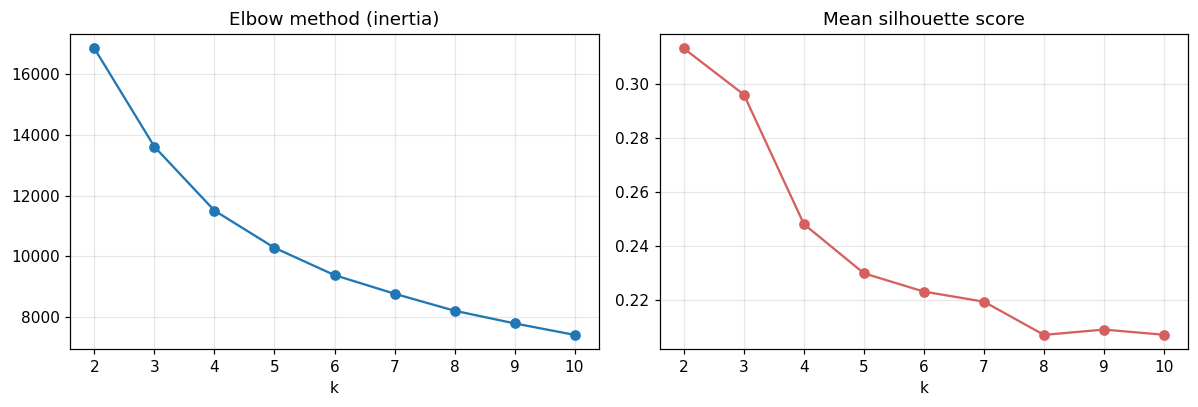

 k  inertia  silhouette
 2  16857.0      0.3131
 3  13614.0      0.2960
 4  11509.0      0.2482
 5  10283.0      0.2300
 6   9382.0      0.2233
 7   8768.0      0.2195
 8   8207.0      0.2073
 9   7789.0      0.2092
10   7410.0      0.2073


In [2]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("k")
axes[1].plot(list(ks), sils, marker="o", color="#D65F5F")
axes[1].set_title("Mean silhouette score")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()
print(pd.DataFrame({"k": list(ks), "inertia": np.round(inertias, 0),
                    "silhouette": np.round(sils, 4)}).to_string(index=False))

The silhouette curve peaks at k=2 and decays smoothly — the geometric signature of one
continuous cloud being partitioned rather than distinct islands being found (exactly
what the EDA scatter plots predicted). k=2 maximizes the average but merges
behaviorally distinct groups; the elbow flattens around k=3–4. The knife plots decide.

## 3. Silhouette knife plots — the per-cluster audit

The average silhouette can hide a bad partition. The knife plot shows, per cluster,
the sorted silhouette values of its members: a healthy solution has **every cluster's
blade crossing the red average line** and **blade thicknesses (cluster sizes) of the
same order** — a cluster entirely behind the line is parasitic, and one dominant blade
means the partition is really k−1 clusters plus dust.

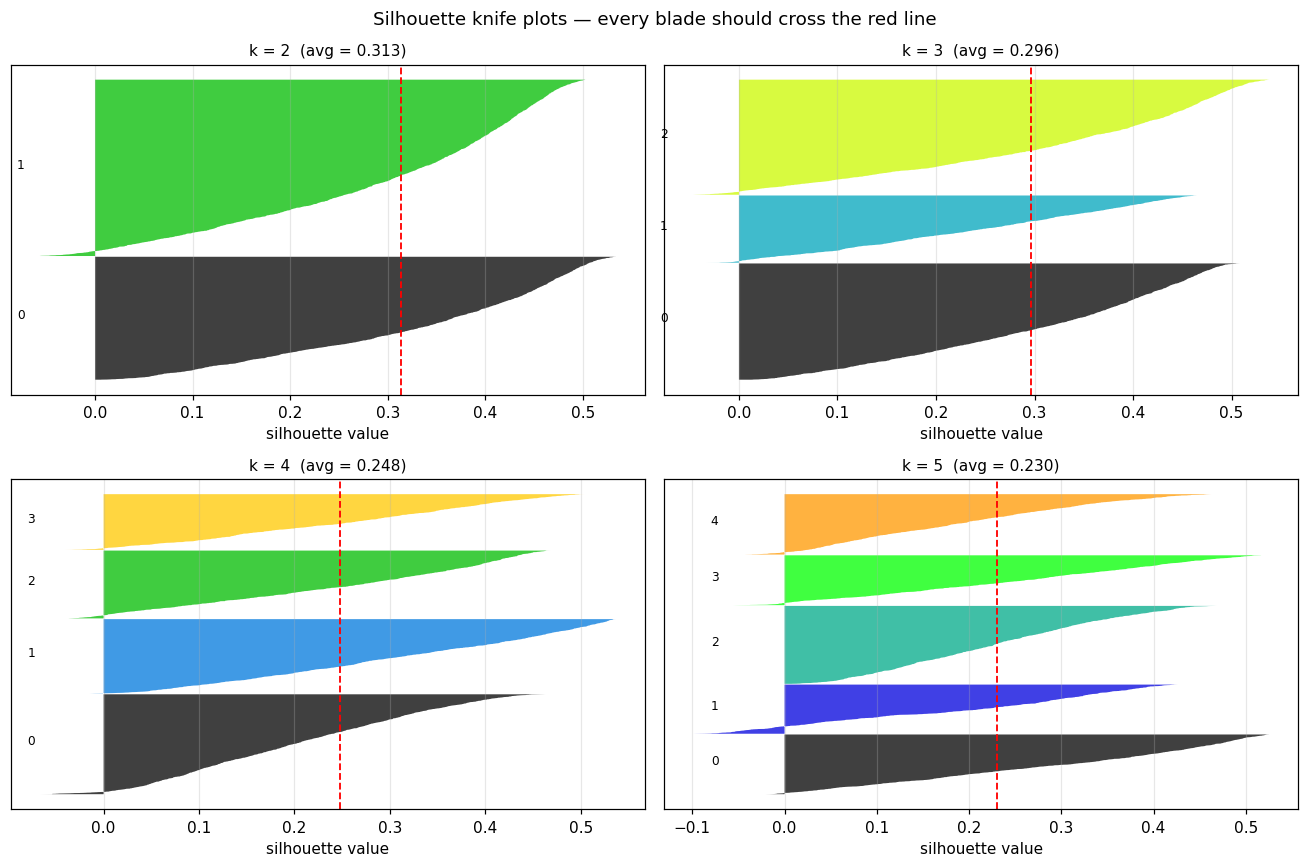

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, k in zip(axes.ravel(), [2, 3, 4, 5]):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    labels = km.labels_
    avg = silhouette_score(X, labels)
    samp = silhouette_samples(X, labels)
    y_lower = 10
    for i in range(k):
        vals = np.sort(samp[labels == i])
        y_upper = y_lower + len(vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=cm.nipy_spectral(float(i) / k), alpha=0.75)
        ax.text(-0.08, y_lower + 0.5 * len(vals), str(i), fontsize=8)
        y_lower = y_upper + 10
    ax.axvline(avg, color="red", ls="--", lw=1.2)
    ax.set_title(f"k = {k}  (avg = {avg:.3f})", fontsize=10)
    ax.set_xlabel("silhouette value")
    ax.set_yticks([])
plt.suptitle("Silhouette knife plots — every blade should cross the red line")
plt.tight_layout()
plt.show()

**Reading the blades:** at k=2 both blades cross the line but the split is coarse
(engaged vs not). At **k=3** all three blades still clear the average, thicknesses are
balanced (≈1.7k / 1.0k / 1.7k), and only thin negative tails appear — the best
structure-vs-granularity trade. From k=4 on, blades slip behind the line and thin
slivers appear: we are slicing a continuum, not discovering clusters.
**Selected: k = 3.**

## 4. Final model & segment profiles

In [4]:
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10).fit(X)
rfm["cluster"] = kmeans.labels_

profile = rfm.groupby("cluster").median().round(1)
profile["n_customers"] = rfm.groupby("cluster").size()
profile["revenue_share"] = (rfm.groupby("cluster").monetary.sum()
                            / rfm.monetary.sum()).round(3)
print("Median profile per cluster:")
print(profile.to_string())

Median profile per cluster:
         recency  frequency  monetary  tenure  n_products  avg_order_value  n_customers  revenue_share
cluster                                                                                               
0          178.0        1.0     348.2   263.0        19.0            209.4         1689          0.084
1           32.0        1.0     379.4    51.0        24.0            283.7          977          0.057
2           20.0        6.0    2092.3   312.0        89.0            364.4         1672          0.859


0    Hibernating one-timers
1         Recent one-timers
2     Loyal high-value core


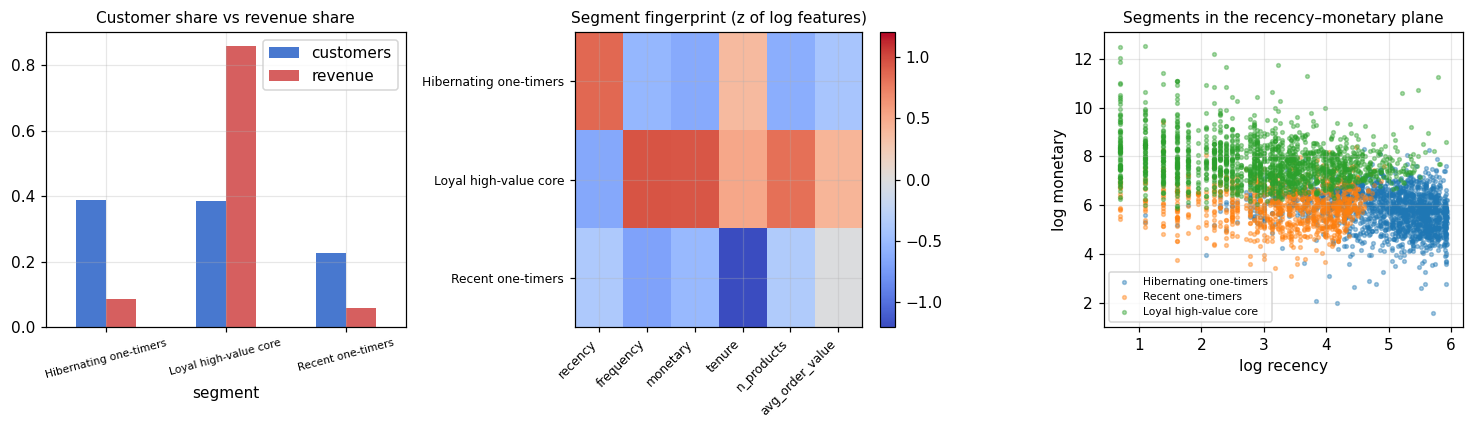

In [5]:
seg_names = {}
med = rfm.groupby("cluster")[["recency", "frequency", "tenure"]].median()
for c in med.index:
    r, f, t = med.loc[c]
    if f >= 3:
        seg_names[c] = "Loyal high-value core"
    elif r <= 60:
        seg_names[c] = "Recent one-timers"
    else:
        seg_names[c] = "Hibernating one-timers"
rfm["segment"] = rfm.cluster.map(seg_names)
print(pd.Series(seg_names, name="segment").to_string())

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
share = rfm.groupby("segment").agg(customers=("cluster", "size"),
                                   revenue=("monetary", "sum"))
share_pct = share / share.sum()
share_pct.plot.bar(ax=axes[0], color=["#4878CF", "#D65F5F"])
axes[0].set_title("Customer share vs revenue share", fontsize=10)
axes[0].tick_params(axis="x", rotation=15, labelsize=7)

logf = np.log1p(rfm[["recency", "frequency", "monetary",
                     "tenure", "n_products", "avg_order_value"]])
zprof = ((logf - logf.mean()) / logf.std()).groupby(rfm.segment).mean()
im = axes[1].imshow(zprof, cmap="coolwarm", vmin=-1.2, vmax=1.2, aspect="auto")
axes[1].set_xticks(range(zprof.shape[1]), zprof.columns, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(zprof.shape[0]), zprof.index, fontsize=8)
plt.colorbar(im, ax=axes[1])
axes[1].set_title("Segment fingerprint (z of log features)", fontsize=10)

for c in sorted(rfm.cluster.unique()):
    sub = rfm[rfm.cluster == c]
    axes[2].scatter(np.log1p(sub.recency), np.log1p(sub.monetary), s=6, alpha=0.4,
                    label=seg_names[c])
axes[2].set_xlabel("log recency")
axes[2].set_ylabel("log monetary")
axes[2].legend(fontsize=7)
axes[2].set_title("Segments in the recency–monetary plane", fontsize=10)
plt.tight_layout()
plt.show()

## 5. The decision layer — one action per segment

| Segment | Size | Revenue share | Signature | Action |
|---|---|---|---|---|
| **Loyal high-value core** | ~39% | **~86%** | R≈20d, F≈6 orders, broad baskets | protect: service quality, early access, churn-watch — this is the business |
| **Recent one-timers** | ~23% | ~6% | first purchase within ~2 months | convert: onboarding journey, second-purchase incentive while the relationship is warm |
| **Hibernating one-timers** | ~39% | ~8% | one purchase, ~6 months silent | low-cost reactivation only; do not spend premium retention budget here |

The concentration is the headline: **~39% of customers generate ~86% of revenue.**
Segment-blind marketing spend is dominated by any policy that treats these three
groups differently — that is the business case for the clustering.

**Honest note on what k=3 is:** the silhouette analysis shows these are *partitions of
a continuum*, not separated islands. That does not reduce their business value (deciles
are partitions too), but it sets up notebook 03's question: does a density-based
method, which only finds islands, find anything at all here?